# SAE evening project — итоговый отчёт (Блок 4)

Отчёт по SAE, обученному на residual stream GPT-2-small (слой указан в конфиге ниже).

Коротко о пути до этого отчёта: собрали активации → обучили SAE → обнаружили
артефакт BOS/padding-токена в топ-примерах → почистили сбор активаций →
переобучили → интерпретировали фичи. Этот notebook закрывает Блок 4:
честные метрики (без сокращений), гистограмма частот фич по всему словарю,
таблица найденных фич с гипотезами, и раздел "что не успел / что дальше".

**Важно:** этот notebook гоняет GPT-2-small и SAE по-настоящему (нужен GPU
и доступ к HuggingFace) — запускать локально, не в чате.

In [9]:
import sys
import glob
import re
from pathlib import Path

import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import pandas as pd

sys.path.append(".")  # чтобы импортировать sae_model.py из этой же папки
from sae_model import SparseAutoencoder

from transformer_lens.model_bridge import TransformerBridge
from datasets import load_dataset

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
LAYER = 6
HOOK_POINT = "resid_post"
HOOK_NAME = f"blocks.{LAYER}.hook_{HOOK_POINT}"
ACTIVATIONS_DIR = "./activations"
FEATURE_REPORT_PATH = "./feature_report.md"

# Список чекпоинтов для сравнения на графике L0 vs loss recovered.
# Если тренировал только с одной λ - оставь один элемент, график будет
# из одной точки, это нормально для вечерней версии. Допиши строчки сюда,
# если позже обучишь SAE ещё с парой других значений l1_coeff - тогда
# получится настоящий trade-off график, как в полной версии плана.
CHECKPOINTS = [
    ("./checkpoints/sae_dict2048_l1_0.003.pt", "λ=3e-3"),
]

## 1. L0 и loss recovered

**L0** — среднее число ненулевых фич на один токен. Меньше = более разреженно
(это то, к чему мы стремимся, но не любой ценой).

**Loss recovered** — здесь используется честная версия метрики из плана, а не
прокси, которым мы пользовались во время самого обучения для скорости.
Считается через три прогона GPT-2:

- `CE_clean` — обычный loss модели на реальных активациях;
- `CE_zero` — loss, если активации в нашем hook-е занулить целиком
  (максимально плохой сценарий, "пол");
- `CE_recon` — loss, если подменить активации на реконструкцию SAE.

```
loss_recovered = (CE_zero - CE_recon) / (CE_zero - CE_clean)
```

1.0 = SAE вообще не портит модель, 0.0 = как будто занулили активации
целиком. Источник формулы: Bricken et al. 2023 ("Towards Monosemanticity"),
тот же вариант считает SAELens.

In [10]:
def load_sae(checkpoint_path, device=DEVICE):
    ckpt = torch.load(checkpoint_path, map_location=device)
    sae_args = ckpt["args"]
    sae = SparseAutoencoder(sae_args["d_model"], sae_args["dict_size"]).to(device)
    sae.load_state_dict(ckpt["state_dict"])
    sae.eval()
    return sae, sae_args


def compute_l0_from_disk(sae, activations_dir, n_tokens=50_000, device=DEVICE):
    # L0 и доля мёртвых фич прямо по сохранённым активациям с диска -
    # быстро, без повторного прогона через GPT-2.
    paths = sorted(glob.glob(f"{activations_dir}/acts_chunk_*.pt"))
    chunks, total = [], 0
    for p in paths:
        chunk = torch.load(p).float()
        chunks.append(chunk)
        total += chunk.shape[0]
        if total >= n_tokens:
            break
    acts = torch.cat(chunks, dim=0)[:n_tokens].to(device)
    with torch.no_grad():
        features = sae.encode(acts)
    l0 = (features > 0).float().sum(dim=-1).mean().item()
    dead_frac = (features.sum(dim=0) == 0).float().mean().item()
    return l0, dead_frac

In [11]:
def per_token_ce_loss(logits, tokens):
    # CE loss на каждый токен отдельно (не усреднённый в одно число) -
    # логит в позиции i предсказывает tokens[i+1].
    logits = logits[:, :-1, :]
    targets = tokens[:, 1:]
    log_probs = F.log_softmax(logits, dim=-1)
    return -log_probs.gather(-1, targets.unsqueeze(-1)).squeeze(-1)  # [batch, seq-1]


def stream_eval_tokens(model, dataset_name="Salesforce/wikitext",
                        dataset_config="wikitext-103-raw-v1",
                        n_texts=100, ctx_len=256, batch_size=16):
    # Свежие тексты из validation-сплита - для честной, не подогнанной
    # под обучение оценки.
    ds = load_dataset(dataset_name, dataset_config, split="validation", streaming=True)
    ds_iter = iter(ds)
    batches, seen = [], 0
    while seen < n_texts:
        text_batch = []
        for _ in range(batch_size):
            try:
                row = next(ds_iter)
            except StopIteration:
                break
            txt = row.get("text", "").strip()
            if len(txt) > 20:
                text_batch.append(txt)
        if not text_batch:
            break
        tokens = model.to_tokens(text_batch, truncate=True, move_to_device=True)
        tokens = tokens[:, :ctx_len]
        batches.append(tokens)
        seen += tokens.shape[0]
    return batches


def compute_true_loss_recovered(model, sae, hook_name, token_batches, eot_id):
    def zero_hook(value, hook):
        value[:] = 0
        return value

    def recon_hook(value, hook):
        shape = value.shape
        flat = value.reshape(-1, shape[-1])
        with torch.no_grad():
            recon, _ = sae(flat)
        return recon.reshape(shape)

    ce_clean_sum, ce_zero_sum, ce_recon_sum, n_tok = 0.0, 0.0, 0.0, 0

    for tokens in token_batches:
        # маска валидных target-токенов: не считаем loss там, где сами
        # предсказываем BOS/padding - это неинформативно.
        mask = (tokens[:, 1:] != eot_id)
        n_valid = mask.sum().item()
        if n_valid == 0:
            continue

        with torch.no_grad():
            logits_clean = model(tokens)
            # NB: если в твоей версии run_with_hooks ожидает другой формат
            # fwd_hooks - проверь help(model.run_with_hooks), сигнатура
            # библиотек в этом проекте уже пару раз менялась между версиями.
            logits_zero = model.run_with_hooks(tokens, fwd_hooks=[(hook_name, zero_hook)])
            logits_recon = model.run_with_hooks(tokens, fwd_hooks=[(hook_name, recon_hook)])

        loss_clean = per_token_ce_loss(logits_clean, tokens)
        loss_zero = per_token_ce_loss(logits_zero, tokens)
        loss_recon = per_token_ce_loss(logits_recon, tokens)

        ce_clean_sum += (loss_clean * mask).sum().item()
        ce_zero_sum += (loss_zero * mask).sum().item()
        ce_recon_sum += (loss_recon * mask).sum().item()
        n_tok += n_valid

    ce_clean = ce_clean_sum / n_tok
    ce_zero = ce_zero_sum / n_tok
    ce_recon = ce_recon_sum / n_tok
    loss_recovered = (ce_zero - ce_recon) / (ce_zero - ce_clean)
    return loss_recovered, ce_clean, ce_zero, ce_recon

In [12]:
print("Загружаю GPT-2-small...")
model = TransformerBridge.boot_transformers("gpt2", device=DEVICE)
model.enable_compatibility_mode()
model.eval()
eot_id = model.tokenizer.eos_token_id

print("Стримлю тексты для честной оценки (validation split, SAE их не видел)...")
eval_batches = stream_eval_tokens(model, n_texts=100)

results = []
for ckpt_path, label in CHECKPOINTS:
    sae, sae_args = load_sae(ckpt_path)
    l0, dead_frac = compute_l0_from_disk(sae, ACTIVATIONS_DIR)
    loss_recovered, ce_clean, ce_zero, ce_recon = compute_true_loss_recovered(
        model, sae, HOOK_NAME, eval_batches, eot_id
    )
    results.append({
        "label": label,
        "l1_coeff": sae_args["l1_coeff"],
        "dict_size": sae_args["dict_size"],
        "L0": l0,
        "dead_frac": dead_frac,
        "loss_recovered": loss_recovered,
        "CE_clean": ce_clean,
        "CE_zero": ce_zero,
        "CE_recon": ce_recon,
    })
    print(f"{label:>10} | L0={l0:6.1f} | dead={dead_frac*100:5.1f}% | "
          f"loss_recovered={loss_recovered*100:5.1f}%")

Загружаю GPT-2-small...


Loading weights: 100%|██████████| 148/148 [00:00<00:00, 2639.16it/s]


Стримлю тексты для честной оценки (validation split, SAE их не видел)...
    λ=3e-3 | L0=1238.2 | dead=  1.6% | loss_recovered= 94.2%


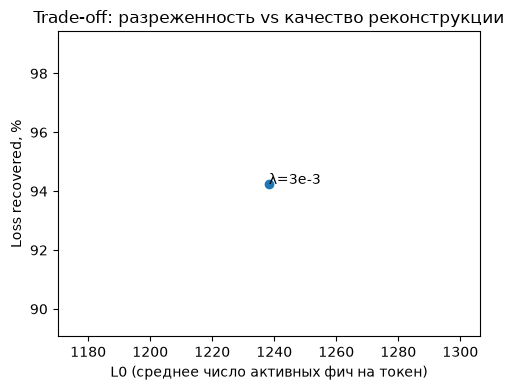

In [13]:
fig, ax = plt.subplots(figsize=(5, 4))
ax.scatter([r["L0"] for r in results], [r["loss_recovered"] * 100 for r in results])
for r in results:
    ax.annotate(r["label"], (r["L0"], r["loss_recovered"] * 100))
ax.set_xlabel("L0 (среднее число активных фич на токен)")
ax.set_ylabel("Loss recovered, %")
ax.set_title("Trade-off: разреженность vs качество реконструкции")
plt.tight_layout()
plt.show()

Если тут пока одна точка — это ожидаемо для вечерней версии с одной λ.
Полноценный Pareto-график (как в разделе "что можно нарастить" исходного
плана) появится, если дообучить SAE ещё с 1-2 значениями `l1_coeff` и
добавить их в список `CHECKPOINTS` выше.

## 2. Гистограмма частот активации фич

Для каждой из `dict_size` фич считаем, на какой доле токенов она вообще
срабатывает. Три зоны, на которые стоит смотреть:

- **пик у нуля** — мёртвые фичи (никогда не срабатывают);
- **основная масса где-то в районе единиц процентов** — это и есть
  потенциально интерпретируемые фичи, ради которых всё затевалось;
- **фичи, срабатывающие на 50%+ токенов** — вероятно, слишком "размазанные",
  как фича #64 из предыдущего прогона интерпретации.

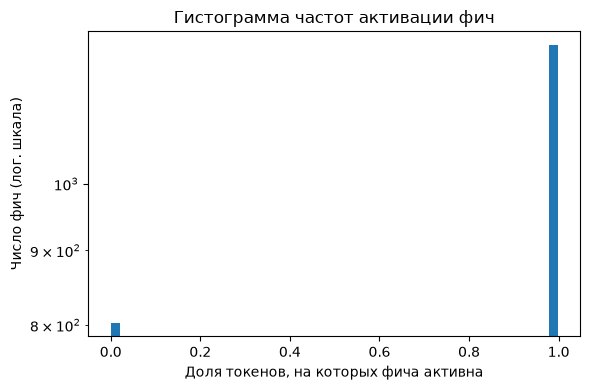

Мёртвых фич (частота = 0): 0 из 2048
'Слишком частых' фич (>50% токенов): 1245


In [14]:
def feature_frequencies(sae, activations_dir, n_tokens=200_000, device=DEVICE):
    paths = sorted(glob.glob(f"{activations_dir}/acts_chunk_*.pt"))
    counts = torch.zeros(sae.dict_size)
    total = 0
    for p in paths:
        chunk = torch.load(p).float().to(device)
        with torch.no_grad():
            features = sae.encode(chunk)
        counts += (features > 0).float().sum(dim=0).cpu()
        total += chunk.shape[0]
        if total >= n_tokens:
            break
    return counts / total  # доля токенов, на которых сработала каждая фича


sae, _ = load_sae(CHECKPOINTS[-1][0])
freqs = feature_frequencies(sae, ACTIVATIONS_DIR)

fig, ax = plt.subplots(figsize=(6, 4))
ax.hist(freqs.numpy(), bins=50)
ax.set_yscale("log")
ax.set_xlabel("Доля токенов, на которых фича активна")
ax.set_ylabel("Число фич (лог. шкала)")
ax.set_title("Гистограмма частот активации фич")
plt.tight_layout()
plt.show()

print(f"Мёртвых фич (частота = 0): {int((freqs == 0).sum())} из {sae.dict_size}")
print(f"'Слишком частых' фич (>50% токенов): {int((freqs > 0.5).sum())}")

## 3. Таблица найденных фич

Подтягиваем `feature_report.md` из Блока 3 и складываем в таблицу.
Столбец "Гипотеза" оставлен пустым намеренно — это единственная часть
отчёта, которую честно нужно заполнить глазами, а не автоматически.

In [15]:
def parse_feature_report(path=FEATURE_REPORT_PATH, n_examples=3):
    text = Path(path).read_text(encoding="utf-8")
    blocks = re.split(r"\n## Фича #", text)[1:]
    rows = []
    for block in blocks:
        feat_id = int(block.split("\n", 1)[0])
        fired_match = re.search(r"Сработала на ([\d,]+) токенах", block)
        fired = fired_match.group(1) if fired_match else "?"
        examples = re.findall(r"\*\*\[(.*?)\]\*\*", block)[:n_examples]
        rows.append({
            "Фича": feat_id,
            "Сработала (токенов)": fired,
            "Примеры токенов": ", ".join(examples),
            "Гипотеза (заполни сам)": "",
        })
    return pd.DataFrame(rows)


feature_table = parse_feature_report()
feature_table

,Фича,Сработала (токенов),Примеры токенов,Гипотеза (заполни сам)
0,809,28318,"', a, '",
1,1601,28317,"meaning, meaning, Thomas",
2,585,28312,"Acc, genetically, Statistical",
3,64,28309,"coasts, impressed, poorly",
4,223,28309,"Rath, ep, Jun",
5,1798,6,"bars, W, .",
6,822,28216,"Vera, Naruto, Technique",
7,1614,28132,"making, made, took",


## 4. Что не успел / что дальше

- **Resampling мёртвых нейронов** — не делали; главной находкой сессии
  оказался не он, а артефакт BOS/padding-токена в сборе активаций.
- **Только одна λ** — для полного Pareto-графика (раздел 1) стоит добавить
  ещё 1-2 значения `l1_coeff` и переобучить.
- **Честный loss recovered** посчитан только здесь, в отчёте — во время
  самого обучения использовалась быстрая прокси-метрика
  (`variance_explained` в `train_sae.py`) ради скорости итерации.
- **Авто-интерпретация через LLM** не автоматизирована в коде: примеры из
  `feature_report.md` можно вручную скопировать в Claude/любую LLM с
  промптом "опиши одним предложением общий паттерн этих фрагментов" и
  сравнить с собственной гипотезой из таблицы выше.
- **Дашборд (Streamlit/Gradio)** — не делали, весь отчёт целиком в этом notebook.
- **Steering** — естественное продолжение: взять decoder-вектор одной
  интерпретируемой фичи (`sae.W_dec[feat_id]`) и прибавлять его к residual
  stream при генерации, посмотреть, как меняется текст.

### Дневник отладки

При сборе активаций топ-примеры сначала указывали на `<|endoftext|>`
(BOS-токен, ~126.6 активации у всех текстов одинаково — явный "attention
sink"), затем на скрытый padding теми же токенами внутри батчей разной
длины. Оба случая исправлены фильтрацией по значению токена в
`collect_activations.py` и `interpret_features.py`, активации пересобраны
и SAE переобучен с нуля. Это тот самый "known limitation → нашли → почему
это не баг, а типичный артефакт (см. Gemma Scope)" пример, который стоит
явно упомянуть в README репозитория — для интерпретируемости такие находки
не менее ценны, чем сами результаты.